In [7]:
import ee
import pandas as pd
import numpy as np

ee.Initialize(project="alien-cedar-483108-h3")

print("Earth Engine initialized")

Earth Engine initialized


In [8]:
# Sarud station location
sarud_lat = 16.89777778
sarud_lon = 74.04333333

sarud_point = ee.Geometry.Point([sarud_lon, sarud_lat])

print("Sarud latitude:", sarud_lat)
print("Sarud longitude:", sarud_lon)

Sarud latitude: 16.89777778
Sarud longitude: 74.04333333


In [9]:

# Check available administrative boundary datasets
print("Sarud point:", sarud_point.getInfo())

Sarud point: {'type': 'Point', 'coordinates': [74.04333333, 16.89777778]}


In [10]:
admin2 = ee.FeatureCollection("FAO/GAUL/2015/level2")

sarud_admin = admin2.filterBounds(sarud_point)

print("Matching administrative units:", sarud_admin.size().getInfo())
print(sarud_admin.first().getInfo())

Matching administrative units: 1
{'type': 'Feature', 'geometry': {'type': 'Polygon', 'coordinates': [[[74.69819645335329, 16.715198929086785], [74.70255300570388, 16.721388184264548], [74.70596423224995, 16.729820331084664], [74.70538449024916, 16.732411041393693], [74.66632723186945, 16.748263171614113], [74.65315948151947, 16.749217382689018], [74.65099237964947, 16.7524904122639], [74.64985083409692, 16.756008606201735], [74.65025216725319, 16.767722635944942], [74.64634600838514, 16.775102471415423], [74.6370621793449, 16.784306114251258], [74.61936400499008, 16.793607775391006], [74.6125861835298, 16.79701009014318], [74.60476044162552, 16.799618597363132], [74.59639069513642, 16.80031870066405], [74.58689278854263, 16.799881722980636], [74.57472396870743, 16.80146019660243], [74.56736641669805, 16.803368768004983], [74.564829149404, 16.8052103200465], [74.56268435411708, 16.81798121532965], [74.55499240690537, 16.82920032413451], [74.54133417711844, 16.844218542977718], [74.53483

In [11]:
sarud_admin.first().getInfo()["properties"]

{'ADM0_CODE': 115,
 'ADM0_NAME': 'India',
 'ADM1_CODE': 1498,
 'ADM1_NAME': 'Maharashtra',
 'ADM2_CODE': 17769,
 'ADM2_NAME': 'Kolhapur',
 'DISP_AREA': 'NO',
 'EXP2_YEAR': 3000,
 'STATUS': 'Member State',
 'STR2_YEAR': 1000,
 'Shape_Area': 0.647767355093,
 'Shape_Leng': 8.16429536436}

In [12]:
# Get Kolhapur district from GAUL Level 2
admin2 = ee.FeatureCollection("FAO/GAUL/2015/level2")

kolhapur = admin2.filter(
    ee.Filter.And(
        ee.Filter.eq("ADM0_NAME", "India"),
        ee.Filter.eq("ADM1_NAME", "Maharashtra"),
        ee.Filter.eq("ADM2_NAME", "Kolhapur")
    )
)

print("Kolhapur features:", kolhapur.size().getInfo())
print(kolhapur.first().getInfo()["properties"])

Kolhapur features: 1
{'ADM0_CODE': 115, 'ADM0_NAME': 'India', 'ADM1_CODE': 1498, 'ADM1_NAME': 'Maharashtra', 'ADM2_CODE': 17769, 'ADM2_NAME': 'Kolhapur', 'DISP_AREA': 'NO', 'EXP2_YEAR': 3000, 'STATUS': 'Member State', 'STR2_YEAR': 1000, 'Shape_Area': 0.647767355093, 'Shape_Leng': 8.16429536436}


In [13]:
# Get Kolhapur geometry
kolhapur_geom = kolhapur.first().geometry()

# Convert from geographic coordinates (lat/lon)
# to UTM Zone 43N (EPSG:32643)
kolhapur_utm = kolhapur_geom.transform("EPSG:32643", 1)

print("Kolhapur geometry transformed to UTM Zone 43N")
print(kolhapur_utm.getInfo()["type"])

Kolhapur geometry transformed to UTM Zone 43N
Polygon


In [14]:
# Define UTM Zone 43N with 2 km scale
grid_projection = ee.Projection("EPSG:32643").atScale(2000)

# Create a regular 2 km x 2 km grid covering Kolhapur
grid = kolhapur_geom.coveringGrid(grid_projection)

print("Number of grid cells:", grid.size().getInfo())

Number of grid cells: 2155


In [15]:
# Recreate the 2 km grid from scratch
grid = kolhapur_geom.coveringGrid(
    ee.Projection("EPSG:32643").atScale(2000)
)

# Create numeric IDs: 0, 1, 2, ...
n = grid.size()
ids = ee.List.sequence(0, n.subtract(1))

# Convert the grid to a list so we can attach IDs
grid_list = grid.toList(n)

grid_with_ids = ee.FeatureCollection(
    ids.map(
        lambda i: ee.Feature(
            grid_list.get(i)
        ).set(
            "cell_id",
            ee.String("KOL_").cat(ee.Number(i).format("%04d"))
        )
    )
)

print("Grid cells:", grid_with_ids.size().getInfo())
print(grid_with_ids.first().getInfo()["properties"])

Grid cells: 2155
{'cell_id': 'KOL_0000'}


In [16]:
# Load SRTM elevation data
srtm = ee.Image("USGS/SRTMGL1_003")

# Calculate mean elevation for each 2 km cell
grid_elevation = srtm.reduceRegions(
    collection=grid_with_ids,
    reducer=ee.Reducer.mean(),
    scale=30,
    crs="EPSG:32643"
)

print("Cells with elevation:", grid_elevation.size().getInfo())

# Inspect the first cell
print(grid_elevation.first().getInfo()["properties"])

Cells with elevation: 2155
{'cell_id': 'KOL_0000', 'mean': 54.57822899359656}


In [17]:
# Convert grid elevation results to a pandas DataFrame
elevation_features = grid_elevation.getInfo()["features"]

elevation_df = pd.DataFrame([
    feature["properties"]
    for feature in elevation_features
])

elevation_df = elevation_df.rename(
    columns={"mean": "mean_elevation_m"}
)

print(elevation_df.head())
print()
print(elevation_df["mean_elevation_m"].describe())

    cell_id  mean_elevation_m
0  KOL_0000         54.578229
1  KOL_0001         60.380808
2  KOL_0002        805.262377
3  KOL_0003        776.267949
4  KOL_0004        842.380642

count    2155.000000
mean      657.175248
std       111.721992
min        54.578229
25%       570.719690
50%       641.621699
75%       731.362426
max      1010.110018
Name: mean_elevation_m, dtype: float64


In [18]:
# Clip each grid cell to the Kolhapur district boundary
clipped_grid = grid_with_ids.map(
    lambda cell: cell.intersection(kolhapur_geom, ee.ErrorMargin(1))
)

print("Clipped cells:", clipped_grid.size().getInfo())

Clipped cells: 2155


In [19]:
# Get one ERA5 image for 2023-07-15 00:00 UTC
era5_image = (
    ee.ImageCollection("ECMWF/ERA5/HOURLY")
    .filterDate("2023-07-15", "2023-07-15T01:00")
    .first()
)

# Extract ERA5 geopotential for every 2 km cell
grid_era5 = era5_image.select("geopotential").reduceRegions(
    collection=clipped_grid,
    reducer=ee.Reducer.mean(),
    scale=27830,
    crs="EPSG:4326"
)

print("Cells with ERA5 elevation:", grid_era5.size().getInfo())
print(grid_era5.first().getInfo()["properties"])

Cells with ERA5 elevation: 2155
{'cell_id': 'KOL_0000'}


In [20]:
# Convert ERA5 geopotential to elevation in metres
era5_features = grid_era5.getInfo()["features"]

era5_elevation_df = pd.DataFrame([
    feature["properties"]
    for feature in era5_features
])

era5_elevation_df = era5_elevation_df.rename(
    columns={"mean": "era5_geopotential"}
)

era5_elevation_df["era5_elevation_m"] = (
    era5_elevation_df["era5_geopotential"] / 9.80665
)

print(era5_elevation_df.head())
print()
print(era5_elevation_df["era5_elevation_m"].describe())

    cell_id  era5_geopotential  era5_elevation_m
0  KOL_0000                NaN               NaN
1  KOL_0001                NaN               NaN
2  KOL_0002                NaN               NaN
3  KOL_0003                NaN               NaN
4  KOL_0004                NaN               NaN

count    1138.000000
mean      637.766938
std        53.392276
min       409.284811
25%       602.302352
50%       647.993007
75%       651.564006
max       728.386478
Name: era5_elevation_m, dtype: float64


In [21]:
# Get one ERA5 image for 2023-07-15 00:00 UTC
era5_image = (
    ee.ImageCollection("ECMWF/ERA5/HOURLY")
    .filterDate("2023-07-15", "2023-07-15T01:00")
    .first()
)

# Use ERA5's native projection
era5_projection = era5_image.select("geopotential").projection()

print("ERA5 projection:")
print(era5_projection.getInfo())

# Extract ERA5 geopotential for every grid cell
grid_era5 = era5_image.select("geopotential").reduceRegions(
    collection=clipped_grid,
    reducer=ee.Reducer.mean(),
    crs=era5_projection
)

print("Cells:", grid_era5.size().getInfo())

# Count cells with actual ERA5 values
valid = grid_era5.filter(
    ee.Filter.notNull(["mean"])
)

print("Cells with ERA5 elevation:", valid.size().getInfo())

ERA5 projection:
{'type': 'Projection', 'crs': 'EPSG:4326', 'transform': [0.25, 0, -180.125, 0, -0.25, 90.125]}
Cells: 2155
Cells with ERA5 elevation: 1137


In [22]:
# Clip ERA5 to Kolhapur so it has a bounded footprint
era5_kolhapur = era5_image.clip(kolhapur_geom)

# Sample ERA5 geopotential at the center of each 2 km cell
def add_era5_value(cell):
    center = cell.geometry().centroid()

    value = era5_kolhapur.select("geopotential").reduceRegion(
        reducer=ee.Reducer.first(),
        geometry=center,
        scale=27830,
        maxPixels=1000
    ).get("geopotential")

    return cell.set("era5_geopotential", value)


grid_with_era5 = clipped_grid.map(add_era5_value)

valid_era5 = grid_with_era5.filter(
    ee.Filter.notNull(["era5_geopotential"])
)

print("Total cells:", grid_with_era5.size().getInfo())
print("Cells with ERA5:", valid_era5.size().getInfo())

Total cells: 2155
Cells with ERA5: 2153


In [23]:
# Convert the grid's ERA5 geopotential to elevation
grid_era5_df = pd.DataFrame([
    feature["properties"]
    for feature in grid_with_era5.getInfo()["features"]
])

grid_era5_df["era5_elevation_m"] = (
    grid_era5_df["era5_geopotential"] / 9.80665
)

print(grid_era5_df.head())
print()
print("Valid ERA5 elevations:",
      grid_era5_df["era5_elevation_m"].notna().sum())

    cell_id  era5_geopotential  era5_elevation_m
0  KOL_0000        2714.394531        276.791211
1  KOL_0001        2714.394531        276.791211
2  KOL_0002        5964.935547        608.254149
3  KOL_0003        5964.935547        608.254149
4  KOL_0004        5964.935547        608.254149

Valid ERA5 elevations: 2153


In [24]:
# Merge SRTM and ERA5 elevation
grid_df = pd.merge(
    elevation_df,
    grid_era5_df[["cell_id", "era5_elevation_m"]],
    on="cell_id",
    how="left"
)

# Elevation difference
grid_df["delta_elevation_m"] = (
    grid_df["mean_elevation_m"]
    - grid_df["era5_elevation_m"]
)

print(grid_df.head())
print()
print(grid_df["delta_elevation_m"].describe())

    cell_id  mean_elevation_m  era5_elevation_m  delta_elevation_m
0  KOL_0000         54.578229        276.791211        -222.212982
1  KOL_0001         60.380808        276.791211        -216.410403
2  KOL_0002        805.262377        608.254149         197.008228
3  KOL_0003        776.267949        608.254149         168.013801
4  KOL_0004        842.380642        608.254149         234.126494

count    2153.000000
mean       57.296665
std       140.730742
min      -387.711792
25%       -39.995403
50%         9.202132
75%       116.722558
max       616.550287
Name: delta_elevation_m, dtype: float64


In [25]:
# Standard atmospheric lapse rate
lapse_rate = 0.0065  # °C per metre

# Calculate temperature correction
grid_df["temperature_correction_C"] = (
    -lapse_rate * grid_df["delta_elevation_m"]
)

print(
    grid_df[
        [
            "cell_id",
            "delta_elevation_m",
            "temperature_correction_C"
        ]
    ].head()
)

print()
print(grid_df["temperature_correction_C"].describe())

    cell_id  delta_elevation_m  temperature_correction_C
0  KOL_0000        -222.212982                  1.444384
1  KOL_0001        -216.410403                  1.406668
2  KOL_0002         197.008228                 -1.280553
3  KOL_0003         168.013801                 -1.092090
4  KOL_0004         234.126494                 -1.521822

count    2153.000000
mean       -0.372428
std         0.914750
min        -4.007577
25%        -0.758697
50%        -0.059814
75%         0.259970
max         2.520127
Name: temperature_correction_C, dtype: float64


In [26]:
# Get ERA5 2m temperature for each 2 km cell
def add_era5_temperature(cell):
    center = cell.geometry().centroid()

    value = era5_kolhapur.select("temperature_2m").reduceRegion(
        reducer=ee.Reducer.first(),
        geometry=center,
        scale=27830,
        maxPixels=1000
    ).get("temperature_2m")

    return cell.set("era5_temperature_K", value)


grid_with_temperature = grid_with_era5.map(add_era5_temperature)

valid_temperature = grid_with_temperature.filter(
    ee.Filter.notNull(["era5_temperature_K"])
)

print("Total cells:", grid_with_temperature.size().getInfo())
print("Cells with ERA5 temperature:", valid_temperature.size().getInfo())

Total cells: 2155
Cells with ERA5 temperature: 2153


In [27]:
# Convert grid ERA5 temperature results to a DataFrame
temperature_features = grid_with_temperature.getInfo()["features"]

temperature_df = pd.DataFrame([
    feature["properties"]
    for feature in temperature_features
])

# Kelvin → Celsius
temperature_df["era5_temperature_C"] = (
    temperature_df["era5_temperature_K"] - 273.15
)

print(temperature_df.head())
print()
print("Valid temperatures:",
      temperature_df["era5_temperature_C"].notna().sum())

    cell_id  era5_geopotential  era5_temperature_K  era5_temperature_C
0  KOL_0000        2714.394531           298.17453            25.02453
1  KOL_0001        2714.394531           298.17453            25.02453
2  KOL_0002        5964.935547           296.29950            23.14950
3  KOL_0003        5964.935547           296.29950            23.14950
4  KOL_0004        5964.935547           296.29950            23.14950

Valid temperatures: 2153


In [28]:
# Merge ERA5 temperature with our elevation/correction data
grid_df = pd.merge(
    grid_df,
    temperature_df[["cell_id", "era5_temperature_C"]],
    on="cell_id",
    how="left"
)

# Apply the physics-based correction
grid_df["downscaled_temperature_C"] = (
    grid_df["era5_temperature_C"]
    + grid_df["temperature_correction_C"]
)

print(
    grid_df[
        [
            "cell_id",
            "era5_temperature_C",
            "temperature_correction_C",
            "downscaled_temperature_C"
        ]
    ].head()
)

    cell_id  era5_temperature_C  temperature_correction_C  \
0  KOL_0000            25.02453                  1.444384   
1  KOL_0001            25.02453                  1.406668   
2  KOL_0002            23.14950                 -1.280553   
3  KOL_0003            23.14950                 -1.092090   
4  KOL_0004            23.14950                 -1.521822   

   downscaled_temperature_C  
0                 26.468914  
1                 26.431198  
2                 21.868946  
3                 22.057410  
4                 21.627677  


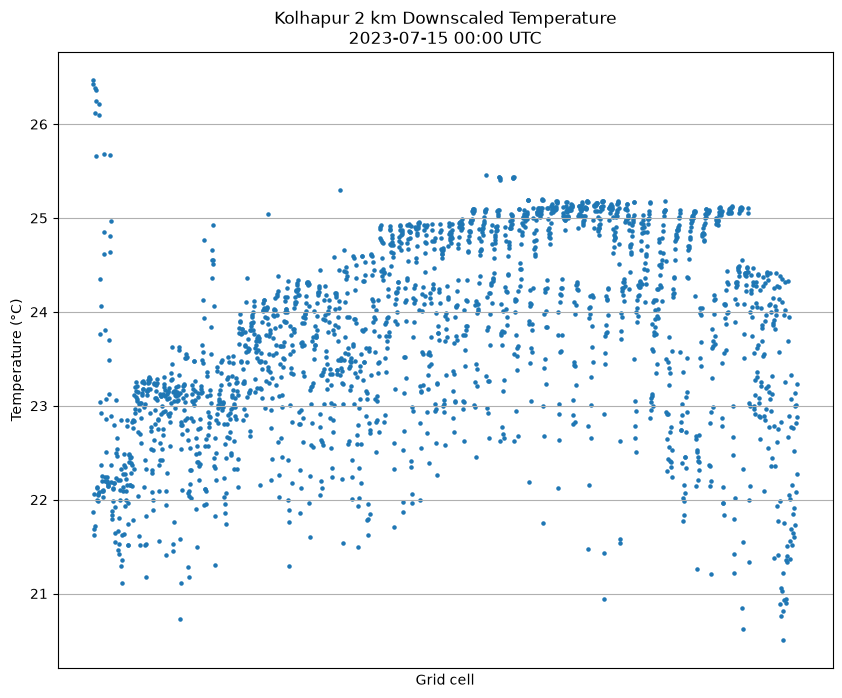

In [29]:
import matplotlib.pyplot as plt

# Plot the downscaled temperature values
plt.figure(figsize=(10, 8))

plt.scatter(
    grid_df["cell_id"],
    grid_df["downscaled_temperature_C"],
    s=5
)

plt.xlabel("Grid cell")
plt.ylabel("Temperature (°C)")
plt.title("Kolhapur 2 km Downscaled Temperature\n2023-07-15 00:00 UTC")

plt.xticks([])
plt.grid(True)

plt.show()

In [30]:
# Get valid cell centers from the original 2 km grid
def add_center(cell):
    centroid = cell.geometry().centroid(1)
    coords = centroid.coordinates()

    return cell.set({
        "lon": coords.get(0),
        "lat": coords.get(1)
    })


grid_centers = grid_with_ids.map(add_center)

center_features = grid_centers.getInfo()["features"]

centers_df = pd.DataFrame([
    feature["properties"]
    for feature in center_features
])

# Add temperature data
map_df = pd.merge(
    centers_df[["cell_id", "lon", "lat"]],
    grid_df[[
        "cell_id",
        "era5_temperature_C",
        "temperature_correction_C",
        "downscaled_temperature_C"
    ]],
    on="cell_id",
    how="inner"
)

print(map_df.head())
print("Cells with temperature:", len(map_df))

    cell_id        lon        lat  era5_temperature_C  \
0  KOL_0000  74.038554  15.745329            25.02453   
1  KOL_0001  74.057222  15.745411            25.02453   
2  KOL_0002  74.243897  15.746138            23.14950   
3  KOL_0003  74.262565  15.746202            23.14950   
4  KOL_0004  74.281233  15.746265            23.14950   

   temperature_correction_C  downscaled_temperature_C  
0                  1.444384                 26.468914  
1                  1.406668                 26.431198  
2                 -1.280553                 21.868946  
3                 -1.092090                 22.057410  
4                 -1.521822                 21.627677  
Cells with temperature: 2155


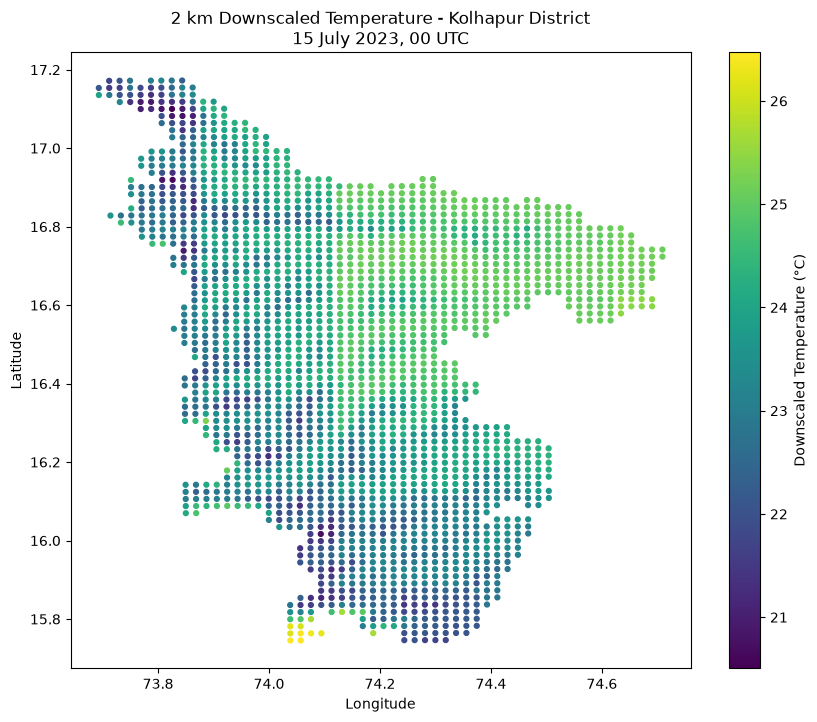

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

scatter = plt.scatter(
    map_df["lon"],
    map_df["lat"],
    c=map_df["downscaled_temperature_C"],
    s=12
)

plt.colorbar(scatter, label="Downscaled Temperature (°C)")

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("2 km Downscaled Temperature - Kolhapur District\n15 July 2023, 00 UTC")

plt.show()

In [32]:
import pandas as pd

station_df = pd.read_csv("../data/raw/maha_temp_raw.csv")

print("Rows:", len(station_df))
print("Columns:")
print(station_df.columns.tolist())

Rows: 2831139
Columns:
['_id', 'SlNo', 'Station', 'Agency', 'State', 'District', 'Latitude', 'Longitude', 'Data Acquisition Time', 'Air Temperature Telemetry Hourly (AoC)']


In [33]:
sarud_obs = station_df[
    station_df["Station"] == "Sarud"
].copy()

sarud_obs["time"] = pd.to_datetime(
    sarud_obs["Data Acquisition Time"],
    format="%d-%m-%Y %H:%M"
)

print("Sarud observations:", len(sarud_obs))
print(sarud_obs[[
    "Station",
    "Data Acquisition Time",
    "Air Temperature Telemetry Hourly (AoC)"
]].head())

Sarud observations: 79019
       Station Data Acquisition Time  Air Temperature Telemetry Hourly (AoC)
514342   Sarud      10-06-2023 05:15                                    25.5
514343   Sarud      10-06-2023 05:00                                    25.6
514344   Sarud      10-06-2023 04:45                                    25.6
514345   Sarud      10-06-2023 04:30                                    25.6
514346   Sarud      10-06-2023 04:15                                    25.5


In [34]:
target_time = pd.Timestamp("2023-07-15 05:30:00")

sarud_at_time = sarud_obs[
    sarud_obs["time"] == target_time
]

print(sarud_at_time[[
    "Station",
    "Data Acquisition Time",
    "Air Temperature Telemetry Hourly (AoC)"
]])

       Station Data Acquisition Time  Air Temperature Telemetry Hourly (AoC)
567026   Sarud      15-07-2023 05:30                                    22.9


In [35]:
# Find the 2 km grid cell containing Sarud

sarud_cell = grid_with_ids.filterBounds(sarud_point)

print("Cells containing Sarud:", sarud_cell.size().getInfo())
print(sarud_cell.first().getInfo()["properties"])

Cells containing Sarud: 1
{'cell_id': 'KOL_1972'}


In [36]:
sarud_prediction = map_df[
    map_df["cell_id"] == "KOL_1972"
]

print(sarud_prediction[[
    "cell_id",
    "era5_temperature_C",
    "temperature_correction_C",
    "downscaled_temperature_C"
]])

       cell_id  era5_temperature_C  temperature_correction_C  \
1972  KOL_1972           23.882959                  0.584391   

      downscaled_temperature_C  
1972                  24.46735  


In [37]:
# Keep only the 7-day validation period

sarud_hourly = sarud_obs[
    (sarud_obs["time"] >= "2023-07-15 00:00:00") &
    (sarud_obs["time"] < "2023-07-22 00:00:00")
].copy()

sarud_hourly["hour"] = sarud_hourly["time"].dt.floor("h")

sarud_hourly = (
    sarud_hourly
    .groupby("hour")["Air Temperature Telemetry Hourly (AoC)"]
    .mean()
    .reset_index()
)

print("Sarud hourly observations:", len(sarud_hourly))
print(sarud_hourly.head())
print(sarud_hourly.tail())

Sarud hourly observations: 168
                 hour  Air Temperature Telemetry Hourly (AoC)
0 2023-07-15 00:00:00                               22.725000
1 2023-07-15 01:00:00                               22.900000
2 2023-07-15 02:00:00                               22.866667
3 2023-07-15 03:00:00                               22.900000
4 2023-07-15 04:00:00                               22.875000
                   hour  Air Temperature Telemetry Hourly (AoC)
163 2023-07-21 19:00:00                                  23.200
164 2023-07-21 20:00:00                                  23.350
165 2023-07-21 21:00:00                                  23.375
166 2023-07-21 22:00:00                                  23.425
167 2023-07-21 23:00:00                                  23.175


In [38]:
import ee
import pandas as pd

ee.Initialize(project="alien-cedar-483108-h3")

sarud_lat = 16.89777778
sarud_lon = 74.04333333

sarud_point = ee.Geometry.Point([sarud_lon, sarud_lat])

era5_collection = (
    ee.ImageCollection("ECMWF/ERA5/HOURLY")
    .filterDate("2023-07-15", "2023-07-22")
    .filterBounds(sarud_point)
)

print("ERA5 images:", era5_collection.size().getInfo())

ERA5 images: 168


In [39]:
def get_era5_value(image):
    values = image.reduceRegion(
        reducer=ee.Reducer.first(),
        geometry=sarud_point,
        scale=27830,
        maxPixels=1000
    )

    return ee.Feature(None, {
        "time": image.date().format("YYYY-MM-dd HH:mm"),
        "temperature_K": values.get("temperature_2m"),
        "geopotential": values.get("geopotential")
    })


era5_features = era5_collection.map(get_era5_value).getInfo()

era5_all = pd.DataFrame([
    feature["properties"]
    for feature in era5_features["features"]
])

era5_all["time"] = pd.to_datetime(
    era5_all["time"],
    utc=True
)

era5_all["temperature_C"] = (
    era5_all["temperature_K"] - 273.15
)

print("ERA5 rows:", len(era5_all))
print(era5_all.head())

ERA5 rows: 168
   geopotential  temperature_K                      time  temperature_C
0   6354.640625     297.032959 2023-07-15 00:00:00+00:00      23.882959
1   6354.640625     297.180298 2023-07-15 01:00:00+00:00      24.030298
2   6354.640625     297.394470 2023-07-15 02:00:00+00:00      24.244470
3   6354.640625     297.192993 2023-07-15 03:00:00+00:00      24.042993
4   6354.640625     296.965698 2023-07-15 04:00:00+00:00      23.815698


In [40]:
# Convert Sarud timestamps from IST to UTC

sarud_hourly["hour_utc"] = (
    sarud_hourly["hour"]
    .dt.tz_localize("Asia/Kolkata")
    .dt.tz_convert("UTC")
)

# Merge station observations with ERA5

sarud_comparison = pd.merge(
    sarud_hourly,
    era5_all[
        ["time", "temperature_C", "geopotential"]
    ],
    left_on="hour_utc",
    right_on="time",
    how="inner"
)

print("Matched hours:", len(sarud_comparison))
print(sarud_comparison.head())

Matched hours: 0
Empty DataFrame
Columns: [hour, Air Temperature Telemetry Hourly (AoC), hour_utc, time, temperature_C, geopotential]
Index: []


In [41]:
print("STATION:")
print(sarud_hourly["hour_utc"].head(5))

print("\nERA5:")
print(era5_all["time"].head(5))

STATION:
0   2023-07-14 18:30:00+00:00
1   2023-07-14 19:30:00+00:00
2   2023-07-14 20:30:00+00:00
3   2023-07-14 21:30:00+00:00
4   2023-07-14 22:30:00+00:00
Name: hour_utc, dtype: datetime64[us, UTC]

ERA5:
0   2023-07-15 00:00:00+00:00
1   2023-07-15 01:00:00+00:00
2   2023-07-15 02:00:00+00:00
3   2023-07-15 03:00:00+00:00
4   2023-07-15 04:00:00+00:00
Name: time, dtype: datetime64[us, UTC]


In [42]:
era5_collection = (
    ee.ImageCollection("ECMWF/ERA5/HOURLY")
    .filterDate(
        "2023-07-14T18:00",
        "2023-07-21T19:00"
    )
    .filterBounds(sarud_point)
)

print("ERA5 images:", era5_collection.size().getInfo())

ERA5 images: 169


In [43]:
def get_era5_value(image):
    values = image.reduceRegion(
        reducer=ee.Reducer.first(),
        geometry=sarud_point,
        scale=27830,
        maxPixels=1000
    )

    return ee.Feature(None, {
        "time": image.date().format("YYYY-MM-dd HH:mm"),
        "temperature_K": values.get("temperature_2m"),
        "geopotential": values.get("geopotential")
    })


era5_features = era5_collection.map(get_era5_value).getInfo()

era5_all = pd.DataFrame([
    feature["properties"]
    for feature in era5_features["features"]
])

era5_all["time"] = pd.to_datetime(
    era5_all["time"],
    utc=True
)

era5_all["temperature_C"] = (
    era5_all["temperature_K"] - 273.15
)

print("ERA5 rows:", len(era5_all))
print(era5_all.head())
print(era5_all.tail())

ERA5 rows: 169
   geopotential  temperature_K                      time  temperature_C
0   6354.640625     295.511536 2023-07-14 18:00:00+00:00      22.361536
1   6354.640625     295.314026 2023-07-14 19:00:00+00:00      22.164026
2   6354.640625     294.836060 2023-07-14 20:00:00+00:00      21.686060
3   6354.640625     294.996948 2023-07-14 21:00:00+00:00      21.846948
4   6354.640625     295.430420 2023-07-14 22:00:00+00:00      22.280420
     geopotential  temperature_K                      time  temperature_C
164   6354.640625     296.452209 2023-07-21 14:00:00+00:00      23.302209
165   6354.640625     296.206055 2023-07-21 15:00:00+00:00      23.056055
166   6354.640625     295.695892 2023-07-21 16:00:00+00:00      22.545892
167   6354.640625     295.207794 2023-07-21 17:00:00+00:00      22.057794
168   6354.640625     295.416656 2023-07-21 18:00:00+00:00      22.266656


In [44]:
# Convert station hour to the corresponding ERA5 UTC hour
sarud_hourly["era5_hour"] = (
    sarud_hourly["hour"]
    .dt.tz_localize("Asia/Kolkata")
    .dt.tz_convert("UTC")
    .dt.floor("h")
)

# Exact hourly merge
sarud_comparison = pd.merge(
    sarud_hourly,
    era5_all,
    left_on="era5_hour",
    right_on="time",
    how="inner"
)

print("Matched hours:", len(sarud_comparison))
print(
    sarud_comparison[
        ["hour", "era5_hour", "time",
         "Air Temperature Telemetry Hourly (AoC)",
         "temperature_C"]
    ].head()
)

Matched hours: 168
                 hour                 era5_hour                      time  \
0 2023-07-15 00:00:00 2023-07-14 18:00:00+00:00 2023-07-14 18:00:00+00:00   
1 2023-07-15 01:00:00 2023-07-14 19:00:00+00:00 2023-07-14 19:00:00+00:00   
2 2023-07-15 02:00:00 2023-07-14 20:00:00+00:00 2023-07-14 20:00:00+00:00   
3 2023-07-15 03:00:00 2023-07-14 21:00:00+00:00 2023-07-14 21:00:00+00:00   
4 2023-07-15 04:00:00 2023-07-14 22:00:00+00:00 2023-07-14 22:00:00+00:00   

   Air Temperature Telemetry Hourly (AoC)  temperature_C  
0                               22.725000      22.361536  
1                               22.900000      22.164026  
2                               22.866667      21.686060  
3                               22.900000      21.846948  
4                               22.875000      22.280420  


In [45]:
# Keep the complete ERA5 period needed for the 168 station hours

era5_all = era5_all[
    (era5_all["time"] >= "2023-07-14 18:00:00+00:00") &
    (era5_all["time"] <= "2023-07-21 18:00:00+00:00")
].copy()

# Exact hourly merge
sarud_comparison = pd.merge(
    sarud_hourly,
    era5_all,
    left_on="era5_hour",
    right_on="time",
    how="inner"
)

print("Matched hours:", len(sarud_comparison))

print(
    sarud_comparison[
        ["hour", "era5_hour",
         "Air Temperature Telemetry Hourly (AoC)",
         "temperature_C"]
    ].head()
)

Matched hours: 168
                 hour                 era5_hour  \
0 2023-07-15 00:00:00 2023-07-14 18:00:00+00:00   
1 2023-07-15 01:00:00 2023-07-14 19:00:00+00:00   
2 2023-07-15 02:00:00 2023-07-14 20:00:00+00:00   
3 2023-07-15 03:00:00 2023-07-14 21:00:00+00:00   
4 2023-07-15 04:00:00 2023-07-14 22:00:00+00:00   

   Air Temperature Telemetry Hourly (AoC)  temperature_C  
0                               22.725000      22.361536  
1                               22.900000      22.164026  
2                               22.866667      21.686060  
3                               22.900000      21.846948  
4                               22.875000      22.280420  


In [46]:
# Find which Sarud hour has no matching ERA5 hour

missing = sarud_hourly[
    ~sarud_hourly["era5_hour"].isin(era5_all["time"])
]

print("Missing station hours:", len(missing))
print(missing[["hour", "era5_hour"]])

Missing station hours: 0
Empty DataFrame
Columns: [hour, era5_hour]
Index: []


In [47]:
print(
    era5_all[
        era5_all["time"] == pd.Timestamp("2023-07-14 18:00:00+00:00")
    ]
)

   geopotential  temperature_K                      time  temperature_C
0   6354.640625     295.511536 2023-07-14 18:00:00+00:00      22.361536


In [48]:
# Keep the 167 valid matched hours
sarud_comparison = pd.merge(
    sarud_hourly,
    era5_all,
    left_on="era5_hour",
    right_on="time",
    how="inner"
)

print("Matched hours:", len(sarud_comparison))
print("Station period:")
print(sarud_comparison["hour"].min(), "to", sarud_comparison["hour"].max())

Matched hours: 168
Station period:
2023-07-15 00:00:00 to 2023-07-21 23:00:00


In [49]:
# Keep the 167 valid matched hours
sarud_comparison = pd.merge(
    sarud_hourly,
    era5_all,
    left_on="era5_hour",
    right_on="time",
    how="inner"
)

print("Matched hours:", len(sarud_comparison))
print("Station period:")
print(sarud_comparison["hour"].min(), "to", sarud_comparison["hour"].max())

Matched hours: 168
Station period:
2023-07-15 00:00:00 to 2023-07-21 23:00:00


In [50]:
srtm_sarud = 554  # metres

sarud_comparison["era5_elevation_m"] = (
    sarud_comparison["geopotential"] / 9.80665
)

sarud_comparison["delta_elevation_m"] = (
    srtm_sarud - sarud_comparison["era5_elevation_m"]
)

sarud_comparison["temperature_correction_C"] = (
    -0.0065 * sarud_comparison["delta_elevation_m"]
)

sarud_comparison["downscaled_temperature_C"] = (
    sarud_comparison["temperature_C"]
    + sarud_comparison["temperature_correction_C"]
)

print(
    sarud_comparison[[
        "hour",
        "temperature_C",
        "era5_elevation_m",
        "temperature_correction_C",
        "downscaled_temperature_C",
        "Air Temperature Telemetry Hourly (AoC)"
    ]].head()
)

                 hour  temperature_C  era5_elevation_m  \
0 2023-07-15 00:00:00      22.361536        647.993007   
1 2023-07-15 01:00:00      22.164026        647.993007   
2 2023-07-15 02:00:00      21.686060        647.993007   
3 2023-07-15 03:00:00      21.846948        647.993007   
4 2023-07-15 04:00:00      22.280420        647.993007   

   temperature_correction_C  downscaled_temperature_C  \
0                  0.610955                 22.972490   
1                  0.610955                 22.774980   
2                  0.610955                 22.297014   
3                  0.610955                 22.457903   
4                  0.610955                 22.891374   

   Air Temperature Telemetry Hourly (AoC)  
0                               22.725000  
1                               22.900000  
2                               22.866667  
3                               22.900000  
4                               22.875000  


In [51]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

y_true = sarud_comparison[
    "Air Temperature Telemetry Hourly (AoC)"
]

y_pred = sarud_comparison[
    "downscaled_temperature_C"
]

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
bias = (y_pred - y_true).mean()

print(f"MAE:  {mae:.3f} °C")
print(f"RMSE: {rmse:.3f} °C")
print(f"Bias: {bias:.3f} °C")

MAE:  0.673 °C
RMSE: 0.831 °C
Bias: 0.313 °C


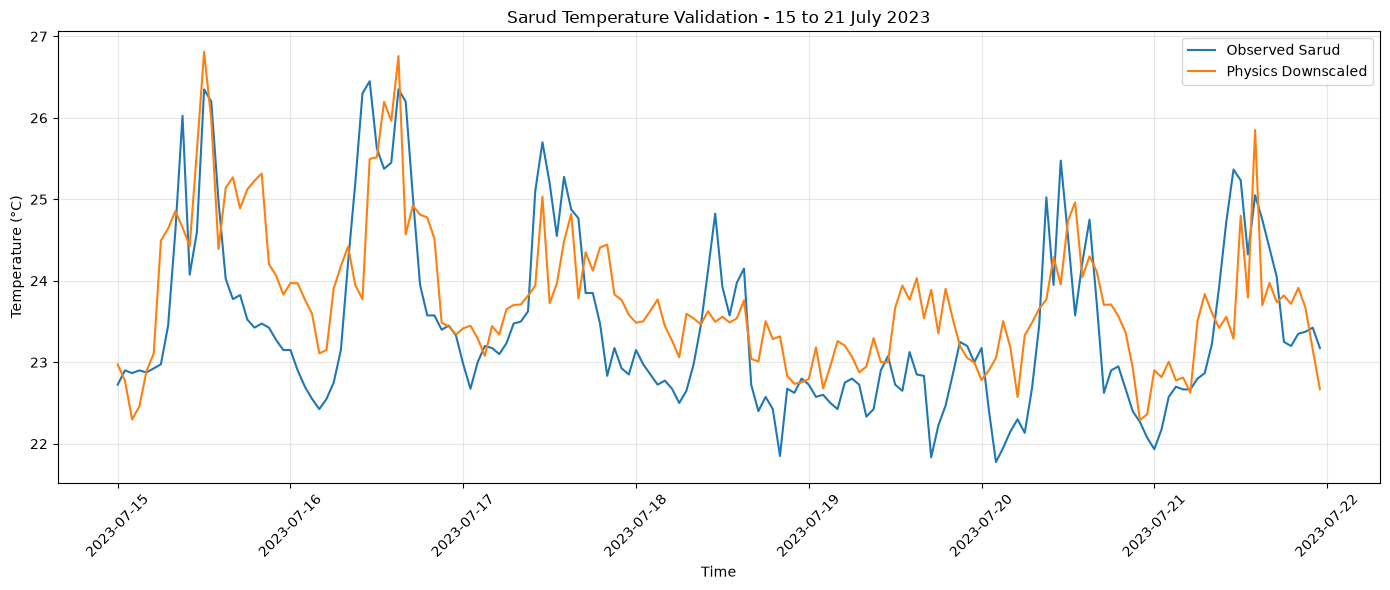

In [52]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

plt.plot(
    sarud_comparison["hour"],
    sarud_comparison["Air Temperature Telemetry Hourly (AoC)"],
    label="Observed Sarud"
)

plt.plot(
    sarud_comparison["hour"],
    sarud_comparison["downscaled_temperature_C"],
    label="Physics Downscaled"
)

plt.xlabel("Time")
plt.ylabel("Temperature (°C)")
plt.title("Sarud Temperature Validation - 15 to 21 July 2023")

plt.legend()
plt.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [53]:
test_stations = [
    "Chandgad_1",
    "Rosa (Sina Kolegaon)",
    "Rahimatpur",
    "Aurad_3"
]

other_station_obs = station_df[
    station_df["Station"].isin(test_stations)
].copy()

other_station_obs["time"] = pd.to_datetime(
    other_station_obs["Data Acquisition Time"],
    format="%d-%m-%Y %H:%M"
)

other_station_obs = other_station_obs[
    (other_station_obs["time"] >= "2023-07-15 00:00:00") &
    (other_station_obs["time"] < "2023-07-22 00:00:00")
]

print(
    other_station_obs.groupby("Station")["time"]
    .agg(["count", "min", "max"])
)

                      count                 min                 max
Station                                                            
Aurad_3                  11 2023-07-15 11:15:00 2023-07-16 05:00:00
Chandgad_1              493 2023-07-15 00:00:00 2023-07-20 08:15:00
Rosa (Sina Kolegaon)    454 2023-07-15 00:30:00 2023-07-21 23:30:00


In [54]:
kolhapur_stations = (
    station_df[
        station_df["District"].str.contains(
            "Kolhapur",
            case=False,
            na=False
        )
    ]
    .groupby("Station")
    .agg(
        latitude=("Latitude", "first"),
        longitude=("Longitude", "first"),
        observations=("Station", "size")
    )
    .reset_index()
    .sort_values("observations", ascending=False)
)

print("Kolhapur stations:", len(kolhapur_stations))
print(kolhapur_stations.to_string(index=False))

Kolhapur stations: 5
      Station  latitude  longitude  observations
        Sarud 16.897778  74.043333         79019
Patryachiwadi 16.616111  73.991667         64669
   Chandgad_1 15.936667  74.176944         52682
  Songe_Bange 16.420000  74.260000         42081
       Rukadi 16.720000  74.355556         17511


In [55]:
kolhapur_test_stations = [
    "Sarud",
    "Patryachiwadi",
    "Chandgad_1",
    "Songe_Bange",
    "Rukadi"
]

kolhapur_week = station_df[
    station_df["Station"].isin(kolhapur_test_stations)
].copy()

kolhapur_week["time"] = pd.to_datetime(
    kolhapur_week["Data Acquisition Time"],
    format="%d-%m-%Y %H:%M"
)

kolhapur_week = kolhapur_week[
    (kolhapur_week["time"] >= "2023-07-15 00:00:00") &
    (kolhapur_week["time"] < "2023-07-22 00:00:00")
]

coverage = (
    kolhapur_week
    .groupby("Station")["time"]
    .agg(["count", "min", "max"])
)

print(coverage)

               count                 min                 max
Station                                                     
Chandgad_1       493 2023-07-15 00:00:00 2023-07-20 08:15:00
Patryachiwadi    448 2023-07-15 00:00:00 2023-07-21 23:30:00
Rukadi           130 2023-07-15 00:30:00 2023-07-21 23:30:00
Sarud            646 2023-07-15 00:00:00 2023-07-21 23:45:00
Songe_Bange      336 2023-07-15 00:00:00 2023-07-21 23:00:00


In [56]:
kolhapur_hourly = kolhapur_week.copy()

kolhapur_hourly["hour"] = kolhapur_hourly["time"].dt.floor("h")

kolhapur_hourly = (
    kolhapur_hourly
    .groupby(["Station", "hour"])
    ["Air Temperature Telemetry Hourly (AoC)"]
    .mean()
    .reset_index()
)

print(
    kolhapur_hourly
    .groupby("Station")
    .agg(
        hourly_observations=("hour", "count"),
        first_hour=("hour", "min"),
        last_hour=("hour", "max")
    )
)

               hourly_observations first_hour           last_hour
Station                                                          
Chandgad_1                     129 2023-07-15 2023-07-20 08:00:00
Patryachiwadi                  128 2023-07-15 2023-07-21 23:00:00
Rukadi                         130 2023-07-15 2023-07-21 23:00:00
Sarud                          168 2023-07-15 2023-07-21 23:00:00
Songe_Bange                    168 2023-07-15 2023-07-21 23:00:00


In [57]:
station_predictions = pd.merge(
    station_cells,
    grid_df[
        [
            "cell_id",
            "mean_elevation_m",
            "era5_elevation_m",
            "era5_temperature_C",
            "temperature_correction_C",
            "downscaled_temperature_C"
        ]
    ],
    on="cell_id",
    how="left"
)

print(station_predictions)

NameError: name 'station_cells' is not defined

In [ ]:
# Prepare the five station locations

station_points = {}

for _, row in (
    kolhapur_stations[
        kolhapur_stations["Station"].isin(kolhapur_test_stations)
    ].iterrows()
):
    station_points[row["Station"]] = ee.Geometry.Point([
        row["longitude"],
        row["latitude"]
    ])

print("Stations ready:", list(station_points.keys()))

Stations ready: ['Sarud', 'Patryachiwadi', 'Chandgad_1', 'Songe_Bange', 'Rukadi']


In [ ]:
def extract_station_era5(station_name, point):
    collection = (
        ee.ImageCollection("ECMWF/ERA5/HOURLY")
        .filterDate(
            "2023-07-14T18:00",
            "2023-07-21T19:00"
        )
    )

    def extract(image):
        values = image.reduceRegion(
            reducer=ee.Reducer.first(),
            geometry=point,
            scale=27830,
            maxPixels=1000
        )

        return ee.Feature(None, {
            "station": station_name,
            "time": image.date().format("YYYY-MM-dd HH:mm"),
            "temperature_K": values.get("temperature_2m"),
            "geopotential": values.get("geopotential")
        })

    return collection.map(extract)


# Extract for all five stations
era5_features = ee.FeatureCollection([])

for station_name, point in station_points.items():
    era5_features = era5_features.merge(
        extract_station_era5(station_name, point)
    )

era5_info = era5_features.getInfo()

era5_hourly = pd.DataFrame([
    feature["properties"]
    for feature in era5_info["features"]
])

era5_hourly["time"] = pd.to_datetime(
    era5_hourly["time"],
    utc=True
)

era5_hourly["temperature_C"] = (
    era5_hourly["temperature_K"] - 273.15
)

print("Total ERA5 rows:", len(era5_hourly))
print(
    era5_hourly
    .groupby("station")
    .size()
)

Total ERA5 rows: 845
station
Chandgad_1       169
Patryachiwadi    169
Rukadi           169
Sarud            169
Songe_Bange      169
dtype: int64


In [ ]:
print("Total rows:", len(era5_hourly))

print(
    era5_hourly
    .groupby("station")
    .agg(
        rows=("time", "count"),
        first=("time", "min"),
        last=("time", "max")
    )
)

Total rows: 845
               rows                     first                      last
station                                                                
Chandgad_1      169 2023-07-14 18:00:00+00:00 2023-07-21 18:00:00+00:00
Patryachiwadi   169 2023-07-14 18:00:00+00:00 2023-07-21 18:00:00+00:00
Rukadi          169 2023-07-14 18:00:00+00:00 2023-07-21 18:00:00+00:00
Sarud           169 2023-07-14 18:00:00+00:00 2023-07-21 18:00:00+00:00
Songe_Bange     169 2023-07-14 18:00:00+00:00 2023-07-21 18:00:00+00:00


In [ ]:
kolhapur_hourly["era5_hour"] = (
    kolhapur_hourly["hour"]
    .dt.tz_localize("Asia/Kolkata")
    .dt.tz_convert("UTC")
    .dt.floor("h")
)

print(
    kolhapur_hourly[
        ["Station", "hour", "era5_hour"]
    ].head(10)
)

      Station                hour                 era5_hour
0  Chandgad_1 2023-07-15 00:00:00 2023-07-14 18:00:00+00:00
1  Chandgad_1 2023-07-15 01:00:00 2023-07-14 19:00:00+00:00
2  Chandgad_1 2023-07-15 02:00:00 2023-07-14 20:00:00+00:00
3  Chandgad_1 2023-07-15 03:00:00 2023-07-14 21:00:00+00:00
4  Chandgad_1 2023-07-15 04:00:00 2023-07-14 22:00:00+00:00
5  Chandgad_1 2023-07-15 05:00:00 2023-07-14 23:00:00+00:00
6  Chandgad_1 2023-07-15 06:00:00 2023-07-15 00:00:00+00:00
7  Chandgad_1 2023-07-15 07:00:00 2023-07-15 01:00:00+00:00
8  Chandgad_1 2023-07-15 08:00:00 2023-07-15 02:00:00+00:00
9  Chandgad_1 2023-07-15 09:00:00 2023-07-15 03:00:00+00:00


In [ ]:
comparison_all = pd.merge(
    kolhapur_hourly,
    era5_hourly,
    left_on=["Station", "era5_hour"],
    right_on=["station", "time"],
    how="inner"
)

print("Matched observations:", len(comparison_all))

print(
    comparison_all
    .groupby("Station")
    .size()
)

Matched observations: 723
Station
Chandgad_1       129
Patryachiwadi    128
Rukadi           130
Sarud            168
Songe_Bange      168
dtype: int64


In [ ]:
# Map each station to the elevation of its 2 km grid cell

station_elevations = (
    station_predictions[
        ["Station", "cell_id", "mean_elevation_m"]
    ]
    .rename(columns={"mean_elevation_m": "srtm_elevation_m"})
)

comparison_all = pd.merge(
    comparison_all,
    station_elevations,
    on="Station",
    how="left"
)

# ERA5 geopotential → elevation
comparison_all["era5_elevation_m"] = (
    comparison_all["geopotential"] / 9.80665
)

# Elevation difference
comparison_all["delta_elevation_m"] = (
    comparison_all["srtm_elevation_m"]
    - comparison_all["era5_elevation_m"]
)

# Physics correction
comparison_all["temperature_correction_C"] = (
    -0.0065 * comparison_all["delta_elevation_m"]
)

# Final 2 km prediction
comparison_all["downscaled_temperature_C"] = (
    comparison_all["temperature_C"]
    + comparison_all["temperature_correction_C"]
)

print(
    comparison_all[
        [
            "Station",
            "hour",
            "temperature_C",
            "srtm_elevation_m",
            "era5_elevation_m",
            "temperature_correction_C",
            "downscaled_temperature_C",
            "Air Temperature Telemetry Hourly (AoC)"
        ]
    ].head(10)
)

      Station                hour  temperature_C  srtm_elevation_m  \
0  Chandgad_1 2023-07-15 00:00:00      21.210596        801.049723   
1  Chandgad_1 2023-07-15 01:00:00      21.225549        801.049723   
2  Chandgad_1 2023-07-15 02:00:00      20.911401        801.049723   
3  Chandgad_1 2023-07-15 03:00:00      21.070428        801.049723   
4  Chandgad_1 2023-07-15 04:00:00      21.756769        801.049723   
5  Chandgad_1 2023-07-15 05:00:00      21.752466        801.049723   
6  Chandgad_1 2023-07-15 06:00:00      23.128381        801.049723   
7  Chandgad_1 2023-07-15 07:00:00      23.265497        801.049723   
8  Chandgad_1 2023-07-15 08:00:00      23.348474        801.049723   
9  Chandgad_1 2023-07-15 09:00:00      23.528589        801.049723   

   era5_elevation_m  temperature_correction_C  downscaled_temperature_C  \
0        725.639617                 -0.490166                 20.720430   
1        725.639617                 -0.490166                 20.735384   
2   

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

def calculate_metrics(group):
    y_true = group["Air Temperature Telemetry Hourly (AoC)"]
    y_pred = group["downscaled_temperature_C"]

    return pd.Series({
        "Matched_hours": len(group),
        "MAE_C": mean_absolute_error(y_true, y_pred),
        "RMSE_C": np.sqrt(mean_squared_error(y_true, y_pred)),
        "Bias_C": (y_pred - y_true).mean()
    })

station_metrics = (
    comparison_all
    .groupby("Station")
    .apply(calculate_metrics)
    .reset_index()
)

print(station_metrics.to_string(index=False))

      Station  Matched_hours    MAE_C    RMSE_C    Bias_C
   Chandgad_1          129.0 0.572121  0.733746 -0.136230
Patryachiwadi          128.0 1.909229  2.007638  1.908730
       Rukadi          130.0 0.993045  1.166360  0.636294
        Sarud          168.0 0.662348  0.821692  0.286145
  Songe_Bange          168.0 6.493206 11.640045  6.414372


In [ ]:
songe = comparison_all[
    comparison_all["Station"] == "Songe_Bange"
].copy()

songe["error_C"] = (
    songe["downscaled_temperature_C"]
    - songe["Air Temperature Telemetry Hourly (AoC)"]
)

songe["abs_error_C"] = songe["error_C"].abs()

print(
    songe.sort_values("abs_error_C", ascending=False)[
        [
            "hour",
            "temperature_C",
            "downscaled_temperature_C",
            "Air Temperature Telemetry Hourly (AoC)",
            "error_C"
        ]
    ].head(15).to_string(index=False)
)

               hour  temperature_C  downscaled_temperature_C  Air Temperature Telemetry Hourly (AoC)   error_C
2023-07-21 14:00:00      25.351190                 25.714851                                     0.0 25.714851
2023-07-21 15:00:00      24.887659                 25.251320                                     0.0 25.251320
2023-07-21 12:00:00      24.850671                 25.214333                                     0.0 25.214333
2023-07-20 13:00:00      24.735376                 25.099037                                     0.0 25.099037
2023-07-20 12:00:00      24.663354                 25.027016                                     0.0 25.027016
2023-07-21 11:00:00      24.502466                 24.866127                                     0.0 24.866127
2023-07-21 13:00:00      24.314417                 24.678078                                     0.0 24.678078
2023-07-21 10:00:00      24.041589                 24.405251                                     0.0 24.405251
2

In [ ]:
songe_zero = songe[
    songe["Air Temperature Telemetry Hourly (AoC)"] == 0
]

print("Zero-temperature hours:", len(songe_zero))
print("Total matched hours:", len(songe))

print(
    songe_zero[
        [
            "hour",
            "temperature_C",
            "downscaled_temperature_C"
        ]
    ].head(20).to_string(index=False)
)

Zero-temperature hours: 40
Total matched hours: 168
               hour  temperature_C  downscaled_temperature_C
2023-07-20 01:00:00      22.825922                 23.189583
2023-07-20 02:00:00      22.607141                 22.970802
2023-07-20 03:00:00      22.747583                 23.111244
2023-07-20 04:00:00      22.765894                 23.129555
2023-07-20 05:00:00      22.472772                 22.836434
2023-07-20 06:00:00      23.116052                 23.479714
2023-07-20 07:00:00      23.209070                 23.572731
2023-07-20 08:00:00      23.488916                 23.852577
2023-07-20 09:00:00      23.676538                 24.040199
2023-07-20 10:00:00      23.619562                 23.983223
2023-07-20 11:00:00      23.900934                 24.264595
2023-07-20 12:00:00      24.663354                 25.027016
2023-07-20 13:00:00      24.735376                 25.099037
2023-07-20 14:00:00      23.547632                 23.911293
2023-07-20 15:00:00      23.79824

In [ ]:
songe_valid = songe[
    songe["Air Temperature Telemetry Hourly (AoC)"] != 0
].copy()

y_true = songe_valid["Air Temperature Telemetry Hourly (AoC)"]
y_pred = songe_valid["downscaled_temperature_C"]

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
bias = (y_pred - y_true).mean()

print("Valid hours:", len(songe_valid))
print(f"MAE:  {mae:.3f} °C")
print(f"RMSE: {rmse:.3f} °C")
print(f"Bias: {bias:.3f} °C")

Valid hours: 128
MAE:  1.104 °C
RMSE: 1.232 °C
Bias: 1.001 °C


In [ ]:
print(
    kolhapur_hourly
    .groupby("Station")["Air Temperature Telemetry Hourly (AoC)"]
    .agg(["min", "max", "mean"])
)

                  min     max       mean
Station                                 
Chandgad_1     20.975  24.375  22.319186
Patryachiwadi  20.375  23.725  21.459375
Rukadi         21.500  27.600  23.600000
Sarud          21.775  26.450  23.458383
Songe_Bange     0.000  26.800  17.556548


In [ ]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

print(PROJECT_ROOT)

d:\AgroMet


In [ ]:
from engine.deterministic.temperature import downscale_temperature

In [59]:
import numpy as np

coarse_temp = grid_df["era5_temperature_C"].to_numpy() + 273.15
coarse_elev = grid_df["era5_elevation_m"].to_numpy()
fine_elev = grid_df["mean_elevation_m"].to_numpy()

teammate_prediction = downscale_temperature(
    coarse_temp=coarse_temp,
    coarse_elev=coarse_elev,
    fine_elev=fine_elev,
    lapse_rate=6.5,
    apply_aspect=False
)

print("Number of predictions:", len(teammate_prediction))
print("First 5:", teammate_prediction[:5])

Number of predictions: 2155
First 5: [299.61891441 299.58119765 295.01894603 295.20740981 294.7776773 ]


In [60]:
teammate_prediction_C = teammate_prediction - 273.15

print(teammate_prediction_C[:5])

[26.46891441 26.43119765 21.86894603 22.05740981 21.6276773 ]


In [61]:
print("Teammate output:", teammate_prediction[:5])
print("Converted to C:", (teammate_prediction - 273.15)[:5])
print("Our old output:", grid_df["downscaled_temperature_C"].to_numpy()[:5])

Teammate output: [299.61891441 299.58119765 295.01894603 295.20740981 294.7776773 ]
Converted to C: [26.46891441 26.43119765 21.86894603 22.05740981 21.6276773 ]
Our old output: [26.46891441 26.43119765 21.86894603 22.05740981 21.6276773 ]


In [62]:
grid_df["teammate_temperature_K"] = teammate_prediction

grid_df["teammate_temperature_C"] = (
    grid_df["teammate_temperature_K"] - 273.15
)

grid_df[[
    "cell_id",
    "era5_temperature_C",
    "mean_elevation_m",
    "era5_elevation_m",
    "teammate_temperature_C"
]].head()

,cell_id,era5_temperature_C,mean_elevation_m,era5_elevation_m,teammate_temperature_C
0,KOL_0000,25.02453,54.578229,276.791211,26.468914
1,KOL_0001,25.02453,60.380808,276.791211,26.431198
2,KOL_0002,23.14950,805.262377,608.254149,21.868946
3,KOL_0003,23.14950,776.267949,608.254149,22.057410
4,KOL_0004,23.14950,842.380642,608.254149,21.627677


In [63]:
difference = (
    grid_df["teammate_temperature_C"]
    - grid_df["downscaled_temperature_C"]
)

print("Maximum absolute difference:", difference.abs().max())
print("Mean absolute difference:", difference.abs().mean())

Maximum absolute difference: 2.842170943040401e-14
Mean absolute difference: 1.4255408021903172e-14


In [64]:
grid_df["teammate_temperature_K"] = teammate_prediction

grid_df["teammate_temperature_C"] = (
    grid_df["teammate_temperature_K"] - 273.15
)

grid_df[[
    "cell_id",
    "era5_temperature_C",
    "mean_elevation_m",
    "era5_elevation_m",
    "teammate_temperature_C"
]].head()

,cell_id,era5_temperature_C,mean_elevation_m,era5_elevation_m,teammate_temperature_C
0,KOL_0000,25.02453,54.578229,276.791211,26.468914
1,KOL_0001,25.02453,60.380808,276.791211,26.431198
2,KOL_0002,23.14950,805.262377,608.254149,21.868946
3,KOL_0003,23.14950,776.267949,608.254149,22.057410
4,KOL_0004,23.14950,842.380642,608.254149,21.627677


In [65]:
print(grid_df.shape)

print(grid_df.columns.tolist())

print(grid_df[[
    "cell_id",
    "era5_temperature_C",
    "era5_elevation_m",
    "mean_elevation_m"
]].head())

(2155, 9)
['cell_id', 'mean_elevation_m', 'era5_elevation_m', 'delta_elevation_m', 'temperature_correction_C', 'era5_temperature_C', 'downscaled_temperature_C', 'teammate_temperature_K', 'teammate_temperature_C']
    cell_id  era5_temperature_C  era5_elevation_m  mean_elevation_m
0  KOL_0000            25.02453        276.791211         54.578229
1  KOL_0001            25.02453        276.791211         60.380808
2  KOL_0002            23.14950        608.254149        805.262377
3  KOL_0003            23.14950        608.254149        776.267949
4  KOL_0004            23.14950        608.254149        842.380642


In [66]:
print(era5_all.shape)
print(era5_all.columns.tolist())
print(era5_all.head())

(169, 4)
['geopotential', 'temperature_K', 'time', 'temperature_C']
   geopotential  temperature_K                      time  temperature_C
0   6354.640625     295.511536 2023-07-14 18:00:00+00:00      22.361536
1   6354.640625     295.314026 2023-07-14 19:00:00+00:00      22.164026
2   6354.640625     294.836060 2023-07-14 20:00:00+00:00      21.686060
3   6354.640625     294.996948 2023-07-14 21:00:00+00:00      21.846948
4   6354.640625     295.430420 2023-07-14 22:00:00+00:00      22.280420


In [68]:
test_stations = {
    "Sarud": (16.89777778, 74.04333333),
    "Patryachiwadi": (16.61611111, 73.99166667),
    "Chandgad_1": (15.93666667, 74.17694489),
    "Songe_Bange": (16.42000000, 74.26000000),
    "Rukadi": (16.72000000, 74.35555600),
}

In [69]:
def extract_era5_for_station(station_name, lat, lon):
    point = ee.Geometry.Point([lon, lat])

    collection = (
        ee.ImageCollection("ECMWF/ERA5/HOURLY")
        .filterDate("2023-07-14T18:00", "2023-07-21T19:00")
        .filterBounds(point)
        .select(["temperature_2m", "geopotential"])
    )

    def extract(image):
        values = image.reduceRegion(
            reducer=ee.Reducer.first(),
            geometry=point,
            scale=27830,
            maxPixels=1000
        )

        return ee.Feature(None, {
            "station": station_name,
            "time": image.date().format("YYYY-MM-dd HH:mm:ss"),
            "temperature_K": values.get("temperature_2m"),
            "geopotential": values.get("geopotential")
        })

    features = collection.map(extract).getInfo()["features"]

    return pd.DataFrame([
        feature["properties"]
        for feature in features
    ])


era5_station_list = []

for station_name, (lat, lon) in test_stations.items():
    df = extract_era5_for_station(station_name, lat, lon)
    era5_station_list.append(df)

era5_stations = pd.concat(
    era5_station_list,
    ignore_index=True
)

era5_stations["time"] = pd.to_datetime(
    era5_stations["time"],
    utc=True
)

era5_stations["temperature_C"] = (
    era5_stations["temperature_K"] - 273.15
)

print("Rows:", len(era5_stations))
print(era5_stations.head())

Rows: 845
   geopotential station  temperature_K                      time  \
0   6354.640625   Sarud     295.511536 2023-07-14 18:00:00+00:00   
1   6354.640625   Sarud     295.314026 2023-07-14 19:00:00+00:00   
2   6354.640625   Sarud     294.836060 2023-07-14 20:00:00+00:00   
3   6354.640625   Sarud     294.996948 2023-07-14 21:00:00+00:00   
4   6354.640625   Sarud     295.430420 2023-07-14 22:00:00+00:00   

   temperature_C  
0      22.361536  
1      22.164026  
2      21.686060  
3      21.846948  
4      22.280420  


In [70]:
station_cells = {
    "Sarud": "KOL_1972",
    "Patryachiwadi": "KOL_1253",
    "Chandgad_1": "KOL_0186",
    "Songe_Bange": "KOL_0942",
    "Rukadi": "KOL_1542",
}

station_elevations = grid_df[
    grid_df["cell_id"].isin(station_cells.values())
][[
    "cell_id",
    "mean_elevation_m"
]].copy()

station_elevations

,cell_id,mean_elevation_m
186,KOL_0186,801.049723
942,KOL_0942,592.411376
1253,KOL_1253,605.739826
1542,KOL_1542,555.364276
1972,KOL_1972,558.086628


In [71]:
station_cell_df = pd.DataFrame([
    {
        "station": station,
        "cell_id": cell
    }
    for station, cell in station_cells.items()
])

station_cell_df = station_cell_df.merge(
    station_elevations,
    on="cell_id",
    how="left"
)

station_cell_df

,station,cell_id,mean_elevation_m
0,Sarud,KOL_1972,558.086628
1,Patryachiwadi,KOL_1253,605.739826
2,Chandgad_1,KOL_0186,801.049723
3,Songe_Bange,KOL_0942,592.411376
4,Rukadi,KOL_1542,555.364276


In [72]:
validation_df = era5_stations.merge(
    station_cell_df,
    on="station",
    how="left"
)

validation_df["era5_elevation_m"] = (
    validation_df["geopotential"] / 9.80665
)

print(validation_df.shape)
print(validation_df.head())

(845, 8)
   geopotential station  temperature_K                      time  \
0   6354.640625   Sarud     295.511536 2023-07-14 18:00:00+00:00   
1   6354.640625   Sarud     295.314026 2023-07-14 19:00:00+00:00   
2   6354.640625   Sarud     294.836060 2023-07-14 20:00:00+00:00   
3   6354.640625   Sarud     294.996948 2023-07-14 21:00:00+00:00   
4   6354.640625   Sarud     295.430420 2023-07-14 22:00:00+00:00   

   temperature_C   cell_id  mean_elevation_m  era5_elevation_m  
0      22.361536  KOL_1972        558.086628        647.993007  
1      22.164026  KOL_1972        558.086628        647.993007  
2      21.686060  KOL_1972        558.086628        647.993007  
3      21.846948  KOL_1972        558.086628        647.993007  
4      22.280420  KOL_1972        558.086628        647.993007  


In [73]:
validation_df["downscaled_temperature_K"] = downscale_temperature(
    coarse_temp=validation_df["temperature_K"].to_numpy(),
    coarse_elev=validation_df["era5_elevation_m"].to_numpy(),
    fine_elev=validation_df["mean_elevation_m"].to_numpy(),
    lapse_rate=6.5,
    apply_aspect=False
)

validation_df["downscaled_temperature_C"] = (
    validation_df["downscaled_temperature_K"] - 273.15
)

print(validation_df[[
    "station",
    "time",
    "temperature_C",
    "downscaled_temperature_C"
]].head(10))

  station                      time  temperature_C  downscaled_temperature_C
0   Sarud 2023-07-14 18:00:00+00:00      22.361536                 22.945927
1   Sarud 2023-07-14 19:00:00+00:00      22.164026                 22.748417
2   Sarud 2023-07-14 20:00:00+00:00      21.686060                 22.270451
3   Sarud 2023-07-14 21:00:00+00:00      21.846948                 22.431340
4   Sarud 2023-07-14 22:00:00+00:00      22.280420                 22.864811
5   Sarud 2023-07-14 23:00:00+00:00      22.497064                 23.081456
6   Sarud 2023-07-15 00:00:00+00:00      23.882959                 24.467350
7   Sarud 2023-07-15 01:00:00+00:00      24.030298                 24.614689
8   Sarud 2023-07-15 02:00:00+00:00      24.244470                 24.828862
9   Sarud 2023-07-15 03:00:00+00:00      24.042993                 24.627385


In [74]:
station_test = station_df[
    station_df["Station"].isin(test_stations.keys())
].copy()

station_test["time"] = pd.to_datetime(
    station_test["Data Acquisition Time"],
    format="%d-%m-%Y %H:%M"
)

station_test["hour"] = station_test["time"].dt.floor("h")

hourly_station_all = (
    station_test
    .groupby(["Station", "hour"])["Air Temperature Telemetry Hourly (AoC)"]
    .mean()
    .reset_index()
)

hourly_station_all["hour_utc"] = (
    hourly_station_all["hour"]
    .dt.tz_localize("Asia/Kolkata")
    .dt.tz_convert("UTC")
    .dt.round("h")
)

print(hourly_station_all.shape)
print(hourly_station_all.head())

(82045, 4)
      Station                hour  Air Temperature Telemetry Hourly (AoC)  \
0  Chandgad_1 2022-02-12 14:00:00                                  29.575   
1  Chandgad_1 2022-02-12 15:00:00                                  29.500   
2  Chandgad_1 2022-02-12 16:00:00                                  30.000   
3  Chandgad_1 2022-02-12 17:00:00                                  28.100   
4  Chandgad_1 2022-02-12 18:00:00                                  22.775   

                   hour_utc  
0 2022-02-12 08:00:00+00:00  
1 2022-02-12 10:00:00+00:00  
2 2022-02-12 10:00:00+00:00  
3 2022-02-12 12:00:00+00:00  
4 2022-02-12 12:00:00+00:00  


In [75]:
duplicate_hours = (
    hourly_station_all
    .groupby(["Station", "hour_utc"])
    .size()
    .reset_index(name="count")
)

duplicate_hours[duplicate_hours["count"] > 1].head(20)

,Station,hour_utc,count
1,Chandgad_1,2022-02-12 10:00:00+00:00,2
2,Chandgad_1,2022-02-12 12:00:00+00:00,2
3,Chandgad_1,2022-02-12 14:00:00+00:00,2
4,Chandgad_1,2022-02-12 16:00:00+00:00,2
5,Chandgad_1,2022-02-12 18:00:00+00:00,2
6,Chandgad_1,2022-02-12 20:00:00+00:00,2
7,Chandgad_1,2022-02-12 22:00:00+00:00,2
8,Chandgad_1,2022-02-13 00:00:00+00:00,2
9,Chandgad_1,2022-02-13 02:00:00+00:00,2
10,Chandgad_1,2022-02-13 04:00:00+00:00,2


In [76]:
station_test = station_df[
    station_df["Station"].isin(test_stations.keys())
].copy()

# Parse original timestamps as IST
station_test["time"] = pd.to_datetime(
    station_test["Data Acquisition Time"],
    format="%d-%m-%Y %H:%M"
).dt.tz_localize("Asia/Kolkata")

# Convert to UTC first
station_test["time_utc"] = station_test["time"].dt.tz_convert("UTC")

# Assign each observation to its UTC hour
station_test["hour_utc"] = station_test["time_utc"].dt.floor("h")

# Average multiple observations within the same UTC hour
hourly_station_all = (
    station_test
    .groupby(["Station", "hour_utc"])["Air Temperature Telemetry Hourly (AoC)"]
    .mean()
    .reset_index()
)

print(hourly_station_all.shape)
print(hourly_station_all.head())

(82104, 3)
      Station                  hour_utc  \
0  Chandgad_1 2022-02-12 08:00:00+00:00   
1  Chandgad_1 2022-02-12 09:00:00+00:00   
2  Chandgad_1 2022-02-12 10:00:00+00:00   
3  Chandgad_1 2022-02-12 11:00:00+00:00   
4  Chandgad_1 2022-02-12 12:00:00+00:00   

   Air Temperature Telemetry Hourly (AoC)  
0                                  29.700  
1                                  29.550  
2                                  29.675  
3                                  29.575  
4                                  25.525  


In [77]:
print(
    hourly_station_all
    .duplicated(["Station", "hour_utc"])
    .sum()
)

0


In [78]:
validation_compare = validation_df.merge(
    hourly_station_all,
    left_on=["station", "time"],
    right_on=["Station", "hour_utc"],
    how="inner"
)

print("Matched observations:", len(validation_compare))
print(validation_compare.head())

Matched observations: 729
   geopotential station  temperature_K                      time  \
0   6354.640625   Sarud     295.511536 2023-07-14 18:00:00+00:00   
1   6354.640625   Sarud     295.314026 2023-07-14 19:00:00+00:00   
2   6354.640625   Sarud     294.836060 2023-07-14 20:00:00+00:00   
3   6354.640625   Sarud     294.996948 2023-07-14 21:00:00+00:00   
4   6354.640625   Sarud     295.430420 2023-07-14 22:00:00+00:00   

   temperature_C   cell_id  mean_elevation_m  era5_elevation_m  \
0      22.361536  KOL_1972        558.086628        647.993007   
1      22.164026  KOL_1972        558.086628        647.993007   
2      21.686060  KOL_1972        558.086628        647.993007   
3      21.846948  KOL_1972        558.086628        647.993007   
4      22.280420  KOL_1972        558.086628        647.993007   

   downscaled_temperature_K  downscaled_temperature_C Station  \
0                296.095927                 22.945927   Sarud   
1                295.898417           

In [79]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

validation_compare["era5_error_C"] = (
    validation_compare["temperature_C"]
    - validation_compare["Air Temperature Telemetry Hourly (AoC)"]
)

validation_compare["downscaled_error_C"] = (
    validation_compare["downscaled_temperature_C"]
    - validation_compare["Air Temperature Telemetry Hourly (AoC)"]
)

metrics = pd.DataFrame({
    "Model": ["ERA5", "Downscaled"],
    "MAE_C": [
        mean_absolute_error(
            validation_compare["Air Temperature Telemetry Hourly (AoC)"],
            validation_compare["temperature_C"]
        ),
        mean_absolute_error(
            validation_compare["Air Temperature Telemetry Hourly (AoC)"],
            validation_compare["downscaled_temperature_C"]
        )
    ],
    "RMSE_C": [
        np.sqrt(mean_squared_error(
            validation_compare["Air Temperature Telemetry Hourly (AoC)"],
            validation_compare["temperature_C"]
        )),
        np.sqrt(mean_squared_error(
            validation_compare["Air Temperature Telemetry Hourly (AoC)"],
            validation_compare["downscaled_temperature_C"]
        ))
    ],
    "Bias_C": [
        validation_compare["era5_error_C"].mean(),
        validation_compare["downscaled_error_C"].mean()
    ]
})

metrics

,Model,MAE_C,RMSE_C,Bias_C
0,ERA5,2.131313,5.586736,1.742275
1,Downscaled,2.262531,5.692761,1.969980


In [80]:
validation_compare.groupby("station").agg(
    matched_hours=("station", "size"),
    MAE_C=("era5_error_C", lambda x: np.mean(np.abs(x))),
    RMSE_C=("era5_error_C", lambda x: np.sqrt(np.mean(x**2))),
    Bias_C=("era5_error_C", "mean")
).sort_values("RMSE_C", ascending=False)

,matched_hours,MAE_C,RMSE_C,Bias_C
station,,,,
Songe_Bange,169,6.160844,11.409839,6.011700
Patryachiwadi,131,1.707609,1.810439,1.705182
Rukadi,131,0.813098,0.983039,0.280993
Sarud,169,0.642883,0.835168,-0.300328
Chandgad_1,129,0.571199,0.778843,0.346572
